In [ ]:
#fetching required packages
library(dplyr)
library(readr)
#read data
gold_stock<-read_csv("goldstock.csv")

New names:
• `` -> `...1`
Rows: 2511 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (6): ...1, Close, Volume, Open, High, Low
date (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
#Have a look at the structure of the data
head(gold_stock,6)

...1,Date,Close,Volume,Open,High,Low
<dbl>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,2024-01-19,2029.3,166078,2027.4,2041.9,2022.2
1,2024-01-18,2021.6,167013,2009.1,2025.6,2007.7
2,2024-01-17,2006.5,245194,2031.7,2036.1,2004.6
3,2024-01-16,2030.2,277995,2053.4,2062.8,2027.6
4,2024-01-12,2051.6,250946,2033.2,2067.3,2033.1
5,2024-01-11,2019.2,270624,2029.4,2056.1,2017.3


In [ ]:
#We are converting the data into ascending order
gold_stock<-gold_stock %>% arrange(Date)
head(gold_stock)

...1,Date,Close,Volume,Open,High,Low
<dbl>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2532,2014-01-22,1238.6,80262,1240.5,1243.5,1235.5
2531,2014-01-23,1262.5,41697,1235.1,1267.1,1230.8
2530,2014-01-24,1264.5,34998,1264.3,1273.2,1256.9
2529,2014-01-27,1263.5,63419,1269.9,1280.1,1252.0
2528,2014-01-28,1250.5,81426,1254.9,1261.9,1248.0
2527,2014-01-29,1262.2,115459,1255.8,1270.7,1248.3


In [ ]:
#To create a forecast model for the daily closing gold price, we'll just be extracting the "Date" and "Close" variables.
gold_stock<-gold_stock %>% select(Close)
colnames(gold_stock)<-c("Price")
#The data includes 2,511 days of "Close" pricing history.
NROW(gold_stock)

[1] 2511

# **Exploratory Data Analysis**

In [ ]:
#Basic Statistics
summary(gold_stock)

     Price     
 Min.   :1050  
 1st Qu.:1250  
 Median :1333  
 Mean   :1499  
 3rd Qu.:1806  
 Max.   :2093  

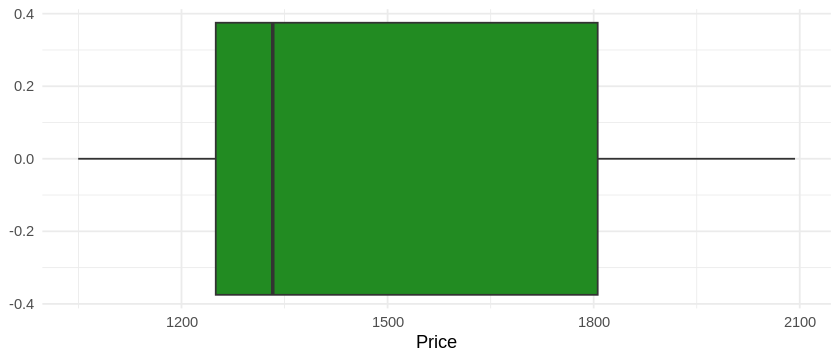

In [ ]:
#Boxplot of Price Variable
library(ggplot2)
g_s1<-gold_stock %>% ggplot()+geom_boxplot(aes(x=Price),fill="forestgreen")+theme_minimal()
options(repr.plot.width=7,repr.plot.height=3)
#First of all, there have been no outliers found
#Secondly, we can observe that the highest number, which was approximately 2,100, was noticeably higher than the median, which was around 1,300.
print(g_s1)

In [ ]:
NROW(gold_stock)

[1] 2511

In [ ]:
NROW(seq(1:NROW(gold_stock)))

[1] 2511

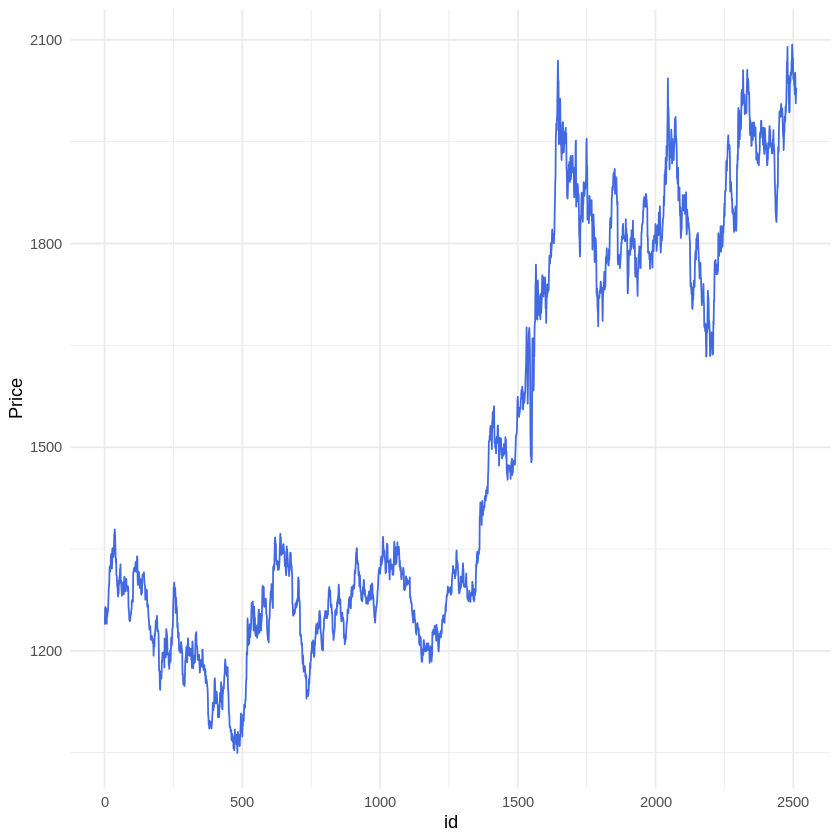

In [ ]:
#Let's draw trendplot
id<-seq(1:NROW(gold_stock))
g_s2<-gold_stock %>% mutate(id=id) %>% ggplot()+geom_line(aes(x=id,y=Price), col="royalblue")+theme_minimal()
options(repr.plt.width=14,repr.plot.height=7)
#The price has slowly went up over the last decade, with a surge after the pandemic due to worldwide uncertainty.
#Seasonality and trend are obvious, indicating the need to make the price stationary for better forecast.
print(g_s2)

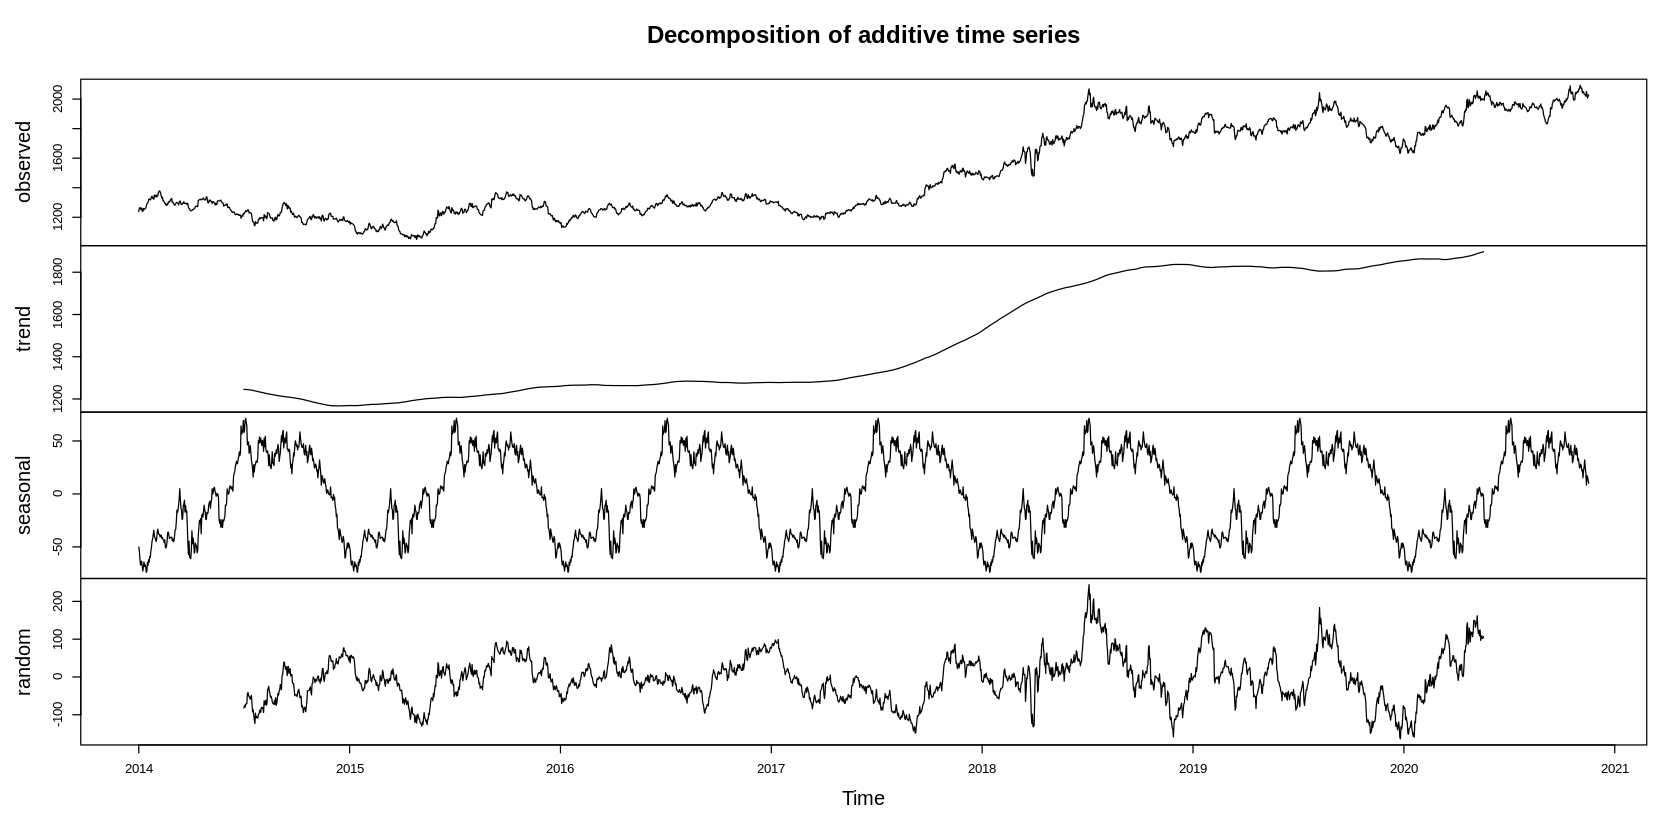

In [ ]:
#To decompose time series data, convert it to 'ts' format
#For daily data, set 'freq' to '365'(a few dates have been omitted, but for convenience, we'll only use the daily data)
gold_ts<-ts(gold_stock$Price,start=c(2014,1),freq=365)
options(repr.plot.width=14,repr.plot.height=7)
#As we looked at previously, a clear "trend" and "seasonal" characteristic is observed
plot(decompose(gold_ts))

# **Data Preparation**

In [ ]:
#Out of 2511 days,we are going to train 80% of the data
#And the remaining 20% will be for testing
print(NROW(gold_ts))
print(NROW(gold_ts)*0.8)

[1] 2511
[1] 2008.8


In [ ]:
#The time period has been shortened as shown below because we omitted skipped dates
#But it makes no difference for the purpose of the daily price forecast merely.
print(start(gold_ts))
print(end(gold_ts))

[1] 2014    1
[1] 2020  321


In [ ]:
# we'll split the time period prior to and following the 183rd day of 2019
NROW(window(gold_ts,end=c(2019,183)))

[1] 2008

In [ ]:
#Splitting the data for traing and testing
train<-window(gold_ts,end=c(2019,183))
test<-window(gold_ts,start=c(2019,184))
print(NROW(train))
print(NROW(test))

[1] 2008
[1] 503


# **ARIMA Model**

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



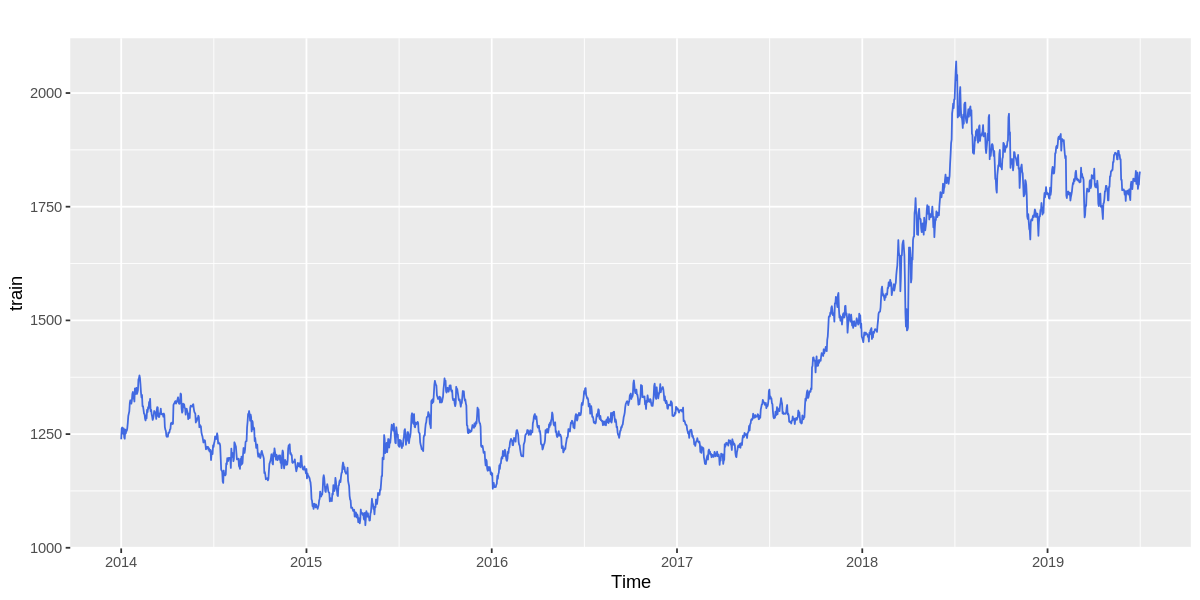

In [ ]:
install.packages('forecast', dependencies = TRUE)
#We must first exclude "trend" from the time series data before building the ARIMA model.
library(forecast)
options(repr.plot.width=10,repr.plot.height=5)
autoplot(train,col="royalblue")

In [ ]:
#Typically, the first degree of difference will be sufficient,
#but we'll double check using the forecast::The ndiffs() method
print(ndiffs(train))
#We'll use the train data's first difference.
train_1d<-diff(train)

[1] 1


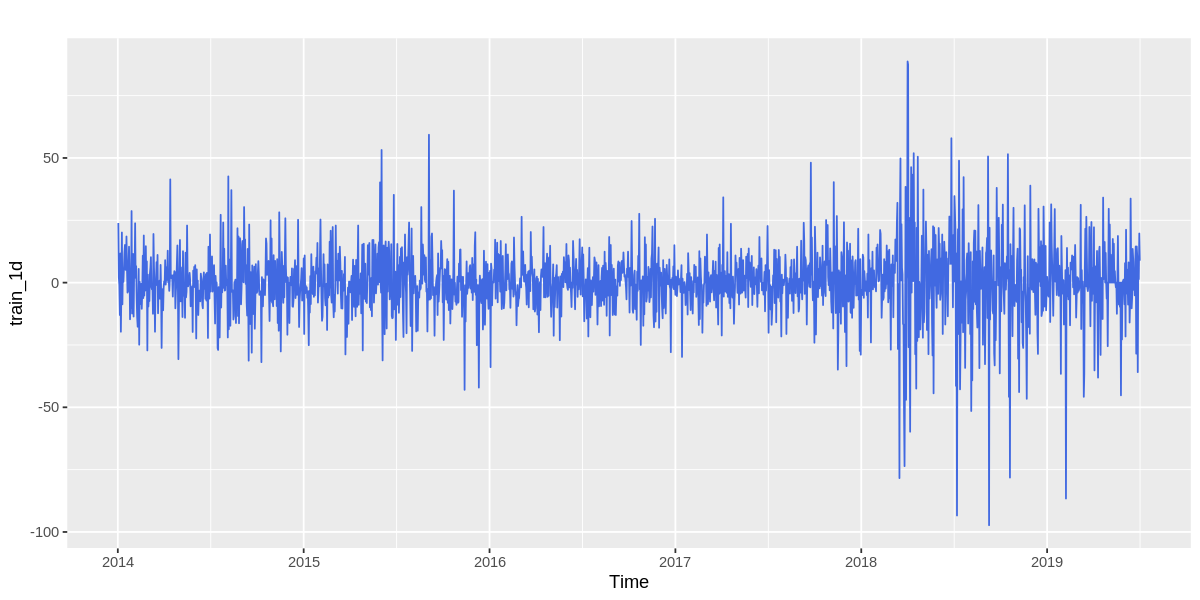

In [ ]:
#Plotting indicates that the "trend" has been effectively eliminated,
#but certain days have very large variances
#For these reasons, we'll return to the original data and use BoxCox Transformation.
autoplot(train_1d,col="royalblue")

In [ ]:
#We will use only the train data to get the best lambda value,
#and then we will modify the test and train data according to that value
train_lambda<-BoxCox.lambda(train)
train_bc<-BoxCox(train,lambda=train_lambda)
test_bc<-BoxCox(test,lambda=train_lambda)

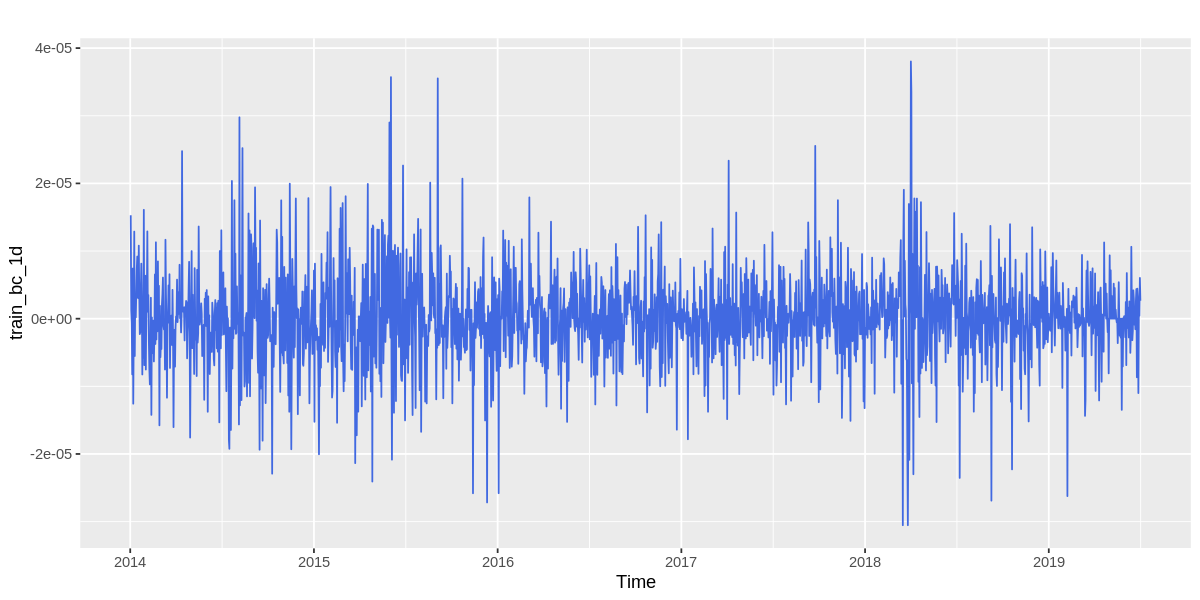

In [ ]:
#The first difference will be applied to the train_bc data as before.
train_bc_1d<-diff(train_bc)
#After the BoxCox Transformation, it looks lot better.
autoplot(train_bc_1d,col="royalblue")

In [ ]:
#Using the ndiffs() function,
#We'll double check even though the differenced graphic no longer appears to have any seasonal characteristics.
print(ndiffs(train_bc_1d))

[1] 0


In [ ]:
#Augmented Dickey-Fuller Test will be used on differenced data to make sure
library(tseries)
#Now that the p-value is sufficiently minimal (<0.05), we can confirm that the data is stationary.
adf.test(train_bc_1d)

Warning message in adf.test(train_bc_1d):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  train_bc_1d
Dickey-Fuller = -12.036, Lag order = 12, p-value = 0.01
alternative hypothesis: stationary


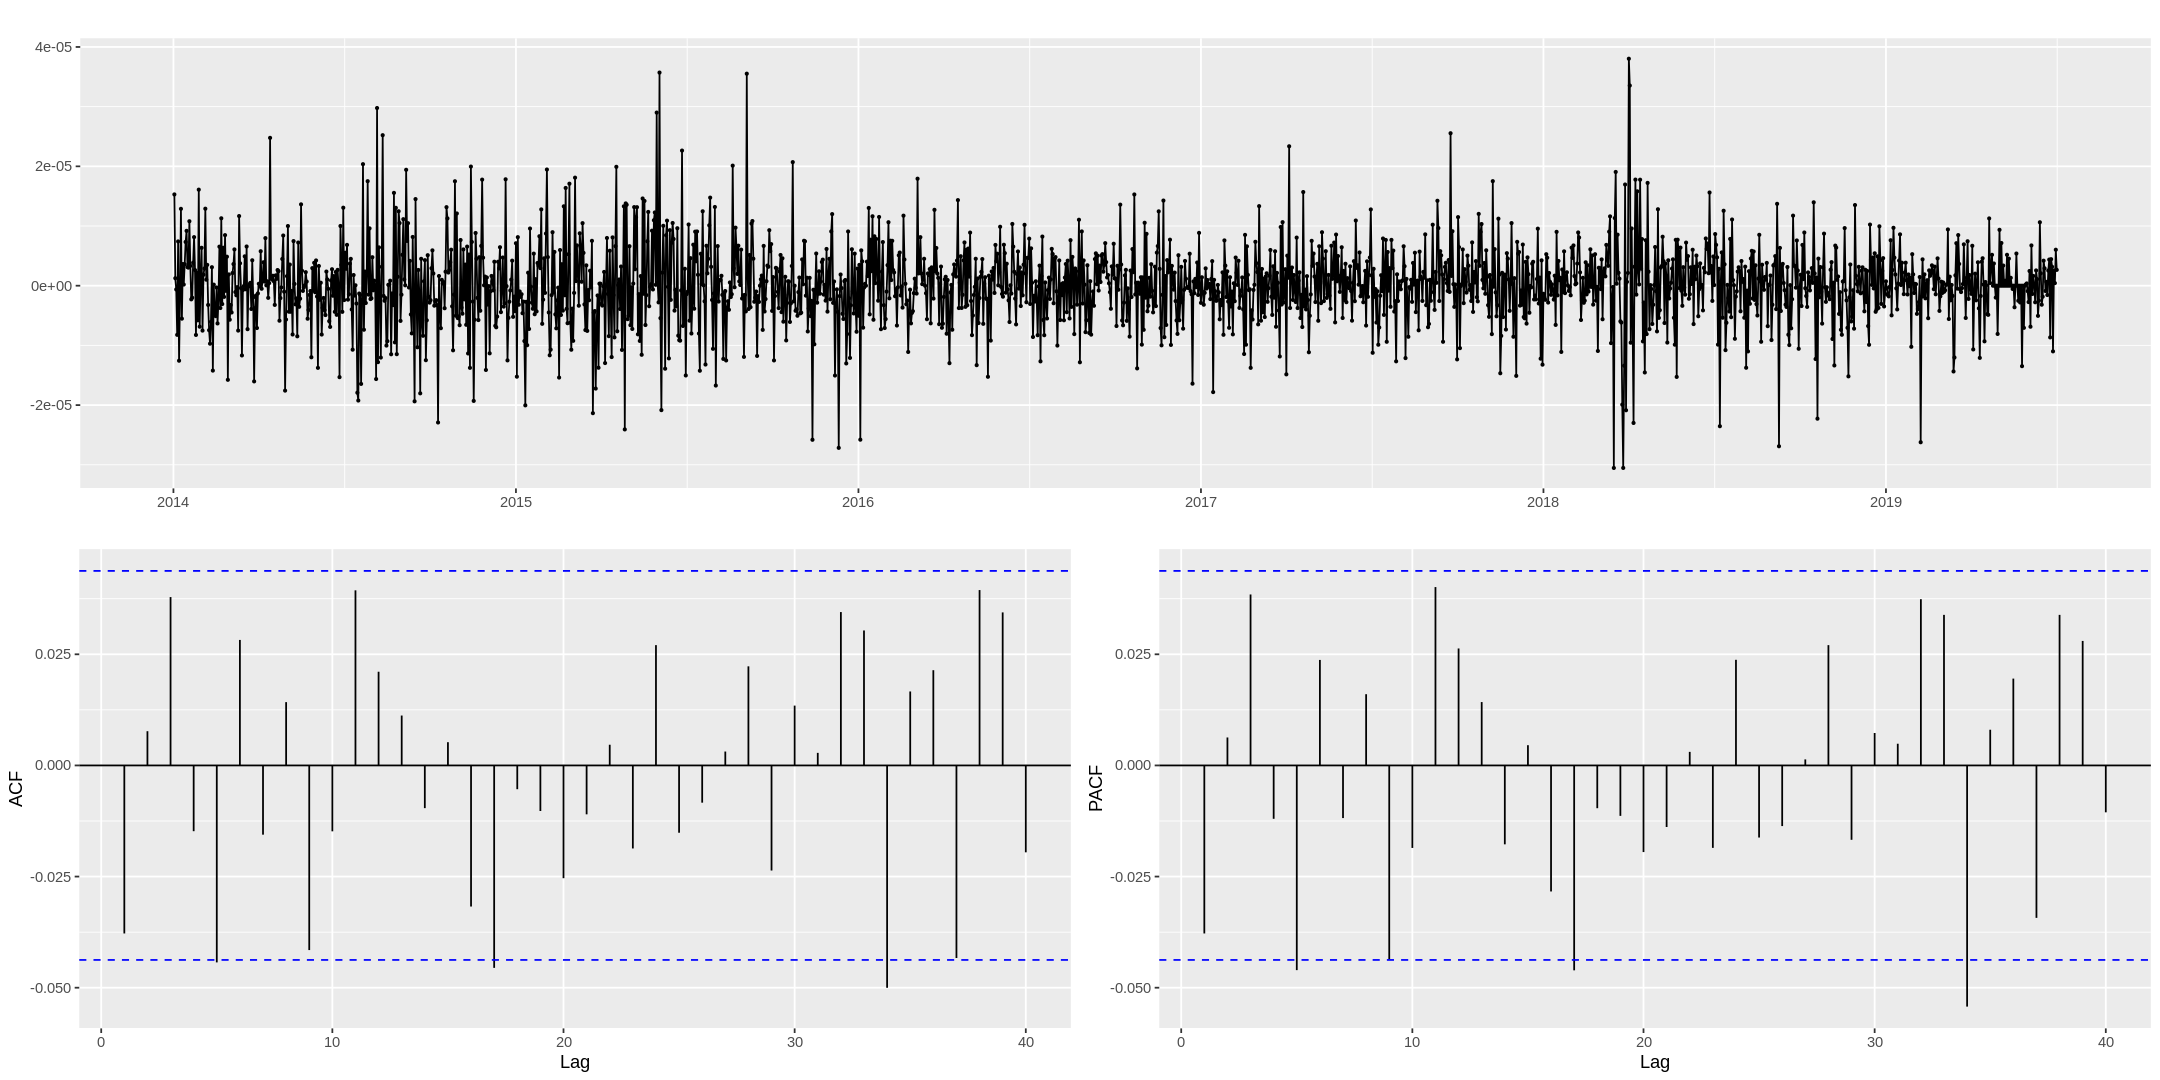

In [ ]:
#At this point, ACF and PACF plots should be used to verify AR and MA degrees.
options(repr.plot.width=18,repr.plot.height=9)
# for about 2 out of 40 lags may be more than the margin, and it appears that all of the AR and MA degrees may be 0.
#In this case, ARIMA(0,1,0) may be an effective model.
ggtsdisplay(train_bc_1d,lag.max=40)

In [ ]:
#let's observe the auto.arima() function,
#the ARIMA(1,1,0) model is suggested.
auto.arima(train_bc)

Series: train_bc 
ARIMA(1,1,0) 

Coefficients:
          ar1
      -0.0373
s.e.   0.0223

sigma^2 = 5.427e-10:  log likelihood = 21062.5
AIC=-42121.01   AICc=-42121   BIC=-42109.8

In [ ]:
#Thus, we'll develop two models ARIMA(0,1,0) and ARIMA(1,1,0).
arima_010<-Arima(train_bc,order=c(0,1,0))
arima_110<-Arima(train_bc,order=c(1,1,0))

In [ ]:
summary(arima_010)

Series: train_bc 
ARIMA(0,1,0) 

sigma^2 = 5.425e-10:  log likelihood = 21061.11
AIC=-42120.21   AICc=-42120.21   BIC=-42114.61

Training set error measures:
                       ME         RMSE          MAE          MPE        MAPE
Training set 6.272505e-07 2.328527e-05 5.227506e-06 6.276707e-05 0.000523104
                   MASE       ACF1
Training set 0.06035531 0.01079299

In [ ]:
summary(arima_110)

Series: train_bc 
ARIMA(1,1,0) 

Coefficients:
          ar1
      -0.0373
s.e.   0.0223

sigma^2 = 5.427e-10:  log likelihood = 21062.5
AIC=-42121.01   AICc=-42121   BIC=-42109.8

Training set error measures:
                       ME         RMSE          MAE          MPE         MAPE
Training set 6.320545e-07 2.328392e-05 5.223003e-06 6.324768e-05 0.0005226532
                   MASE       ACF1
Training set 0.06030331 0.01392941

# **Forecast**

In [ ]:
#we'll forecast the next 503 days.
NROW(test_bc)

[1] 503

In [ ]:
arima_010_pred<-forecast(arima_010,h=503)

In [ ]:
arima_110_pred<-forecast(arima_110,h=503)

In [ ]:
#To plot them all at once, we'll apply the same BoxCox Transformation to the original data.
gold_ts_bc<-BoxCox(gold_ts,lambda=train_lambda)

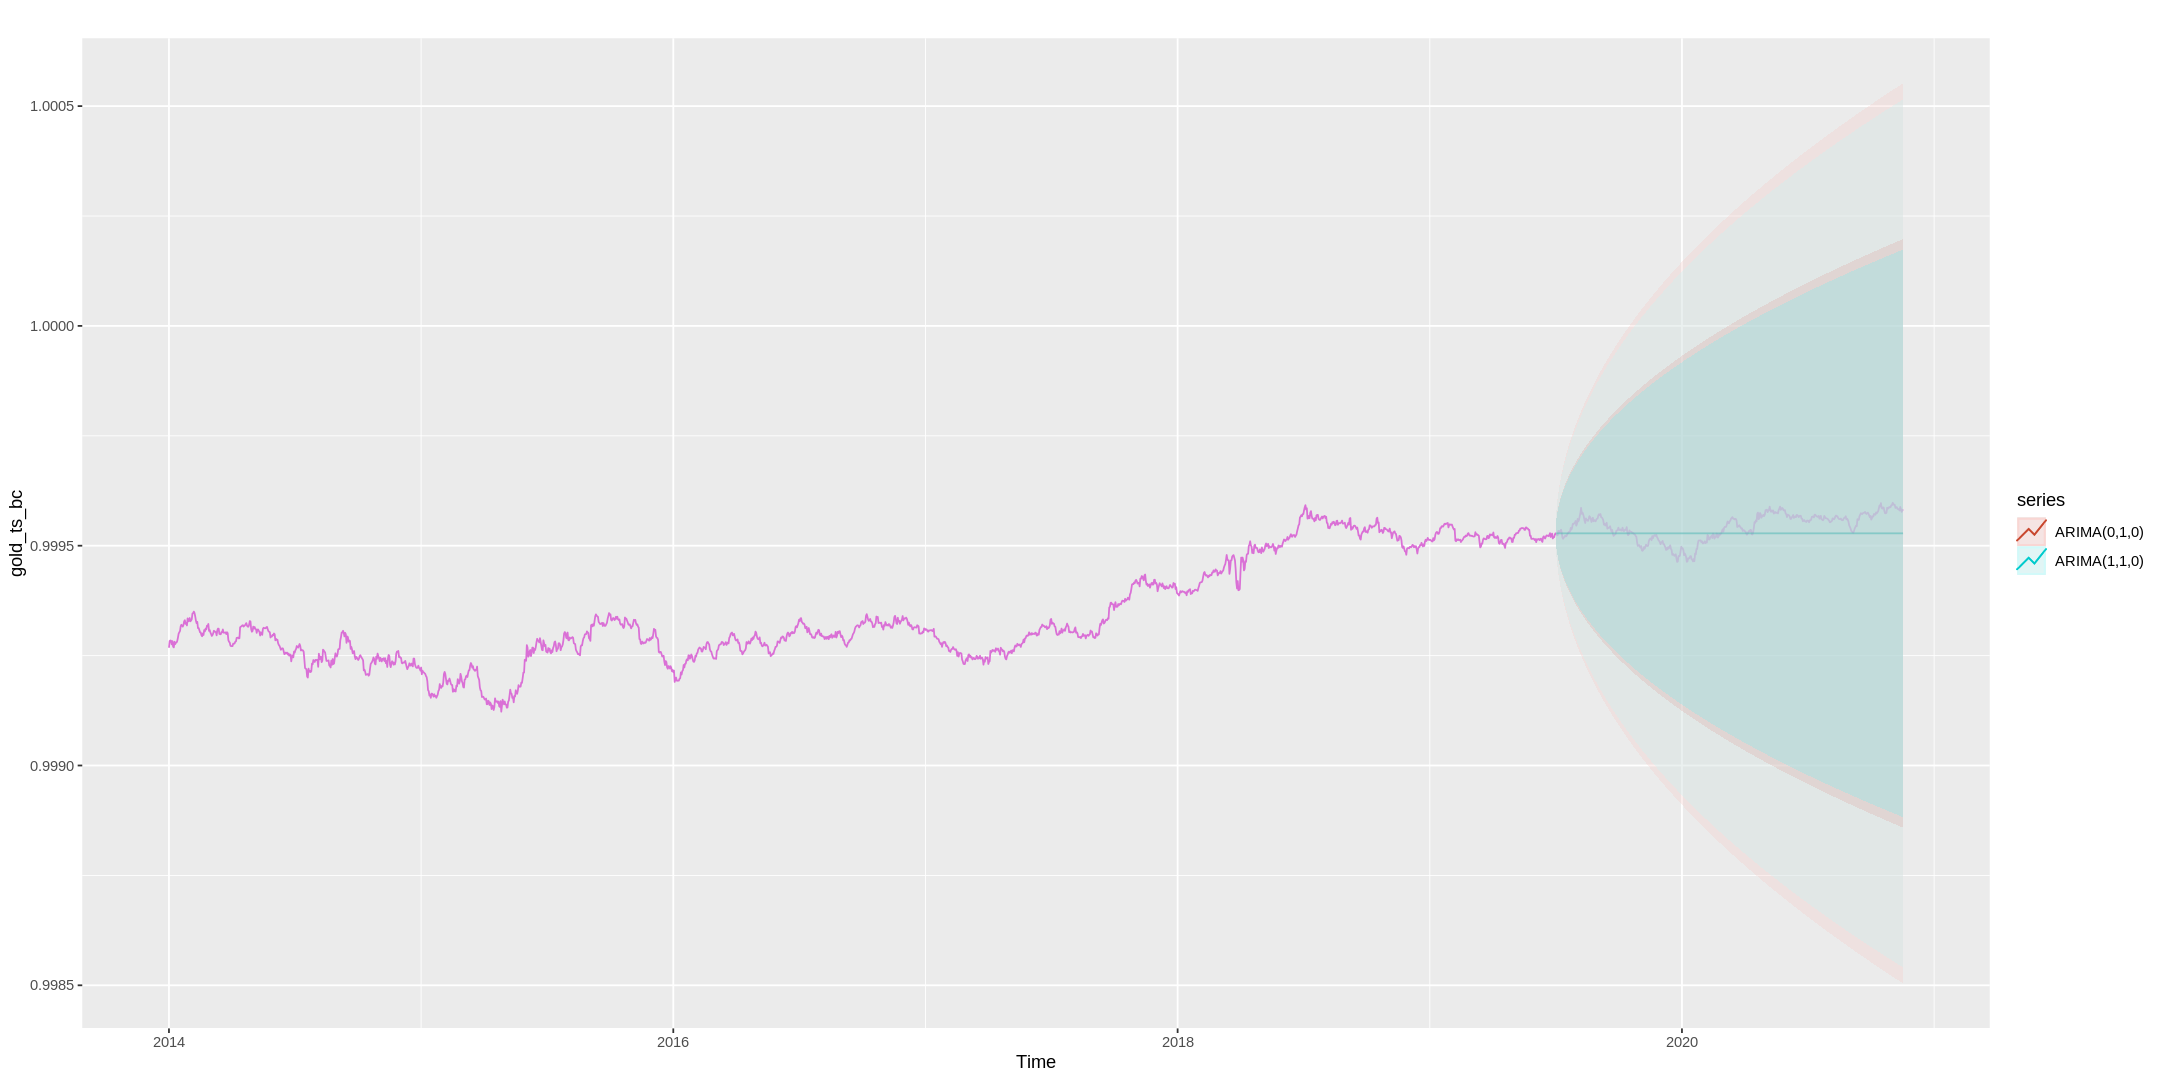

In [ ]:
#The ARIMA(1,1,0) model appears to be somewhat better to the ARIMA(0,1,0) model.
autoplot(gold_ts_bc,col="orchid")+autolayer(arima_010_pred,series="ARIMA(0,1,0)",alpha=.3)+autolayer(arima_110_pred,series="ARIMA(1,1,0)",alpha=.3)

In [ ]:
#We'll Compare two models with metrics such as ME,RMSE,MAE,etc.
accuracy(arima_010_pred,test_bc)
accuracy(arima_110_pred,test_bc)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,6.272505e-07,2.328527e-05,5.227506e-06,6.276707e-05,0.000523104,0.06035531,0.01079299,NA
Test set,1.551365e-05,3.473946e-05,2.982408e-05,1.551977e-03,0.002983751,0.34434041,0.98564418,7.072923


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,6.320545e-07,2.328392e-05,5.223003e-06,6.324768e-05,0.0005226532,0.06030331,0.01392941,NA
Test set,1.560905e-05,3.478217e-05,2.986219e-05,1.561521e-03,0.0029875635,0.34478043,0.98564429,7.081618
